In [1]:
import math
import pandas as pd

# Given
N_A = 10
N_B = 10
q_tot = 20

# Store each macrostate
data = []

for q_A in range(q_tot + 1):

    # Energy conservation
    q_B = q_tot - q_A

    # Multiplicity of each Einstein solid
    omega_A = math.comb(q_A + N_A - 1, q_A)
    omega_B = math.comb(q_B + N_B - 1, q_B)

    # Multiplicity of this macrostate
    omega_total = omega_A * omega_B

    # Add row to data
    data.append({
        "q_A": q_A,
        "q_B": q_B,
        "Omega_A": omega_A,
        "Omega_B": omega_B,
        "Omega_total": omega_total
    })

# Convert to Pandas DataFrame
df = pd.DataFrame(data)

# Display table
display(df)

# Sum multiplicities of all macrostates
total_microstates = df["Omega_total"].sum()

print(f"Total number of microstates = {total_microstates:,}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



,q_A,q_B,Omega_A,Omega_B,Omega_total
0,0,20,1,10015005,10015005
1,1,19,10,6906900,69069000
2,2,18,55,4686825,257775375
3,3,17,220,3124550,687401000
4,4,16,715,2042975,1460727125
5,5,15,2002,1307504,2617623008
6,6,14,5005,817190,4090035950
7,7,13,11440,497420,5690484800
8,8,12,24310,293930,7145438300
9,9,11,48620,167960,8166215200


Total number of microstates = 68,923,264,410


Minimum N for 1% precision: 90


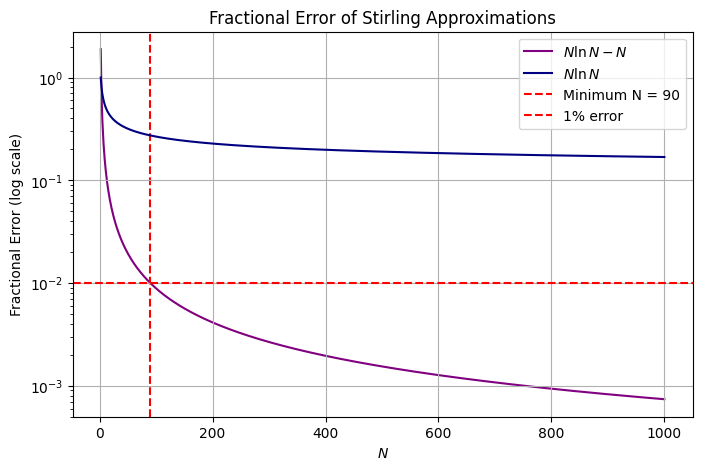

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

# N values
N = np.arange(2, 1001)

# Exact ln(N!)
exact = gammaln(N + 1)

# Stirling approximations
stirling_1 = N*np.log(N) - N
stirling_2 = N*np.log(N)

# Fractional errors
error_1 = np.abs(stirling_1 - exact) / exact
error_2 = np.abs(stirling_2 - exact) / exact

# Find first N with <= 1% error
valid = N[error_1 <= 0.01]
N_min = valid[0]

print("Minimum N for 1% precision:", N_min)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(N, error_1, label=r"$N\ln N-N$", color = "purple", zorder = 1)
plt.plot(N, error_2, label=r"$N\ln N$", color = "navy", zorder= 3)

plt.axvline(N_min, linestyle="--", label=f"Minimum N = {N_min}", color = "red", zorder=1)

# 1% error line
plt.axhline(0.01, linestyle="--", label="1% error", color = "red", zorder=2)
plt.xlabel(r"$N$")
plt.ylabel("Fractional Error (log scale)")
plt.title("Fractional Error of Stirling Approximations")
plt.yscale("log")
plt.legend()
plt.grid()

plt.show()